In [21]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

In [22]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
(1000, 8)
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'w

In [23]:
print(df['math score'].mean())
#average of math score...

66.089


In [24]:
print(df['reading score'].max())
#maximum values in reading score...

100


In [25]:
df.groupby('gender').mean(numeric_only=True)
#average of all female students & male students...

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


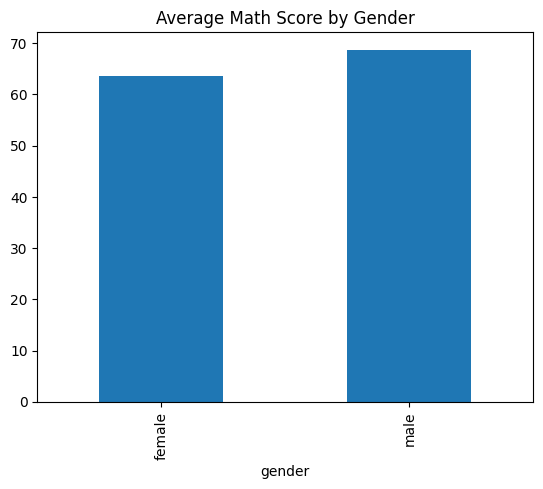

In [26]:
import matplotlib.pyplot as plt

df.groupby('gender')['math score'].mean().plot(kind='bar')

plt.title("Average Math Score by Gender")
plt.show()

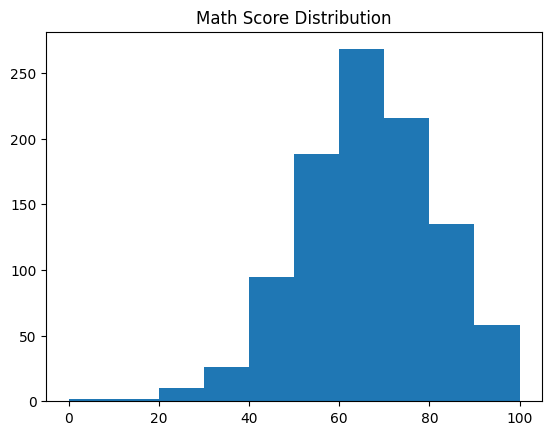

In [27]:
plt.hist(df['math score'])
plt.title("Math Score Distribution")
plt.show()

In [28]:
X = df[['math score', 'reading score']]
y = df['writing score']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(predictions)
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)

print(error)


[85.59822883 64.17343143 72.63647191 75.96410913 82.29300047 74.58185589
 69.04967819 59.55634117 73.12921131 52.78269291 45.79787062 25.05457777
 78.2838587  62.95436974 80.48839918 76.26808337 51.04848296 45.56428772
 56.32150416 63.44710914 71.62858425 49.40707321 70.17277493 50.78932646
 78.26144983 74.51146455 72.72927212 56.69586974 45.96106217 56.3918955
 60.11947191 60.75299399 61.99446455 70.4799139  76.66802256 51.42284854
 77.11277948 75.61215242 76.83121411 14.50537063 74.65224723 65.01812754
 60.47142862 61.43133381 86.46533381 61.78329053 69.4016349  27.79667539
 87.33243878 80.72198207 73.87794247 74.32269939 78.19105848 54.44651152
 71.86216714 72.79966346 77.88708425 53.27543231 84.37916714 88.92586605
 40.24328404 82.31540934 76.45684853 59.83790654 87.91797839 72.58848944
 69.00169571 52.40832733 61.71289918 93.40217363 62.27602992 86.76930805
 56.08792127 54.60970308 59.25236694 75.23778684 85.17588078 55.0800336
 63.82147472 50.90770027 60.18986326 36.42290742 77.5

In [29]:
result = pd.DataFrame({
    'Actual Writing Score': y_test,
    'Predicted Writing Score': predictions
})

print(result.head(10))
print("Mean Absolute Error:", error)

     Actual Writing Score  Predicted Writing Score
521                    84                85.598229
737                    73                64.173431
740                    72                72.636472
660                    73                75.964109
411                    78                82.293000
678                    78                74.581856
626                    63                69.049678
513                    62                59.556341
859                    72                73.129211
136                    41                52.782693
Mean Absolute Error: 3.8380082149660915


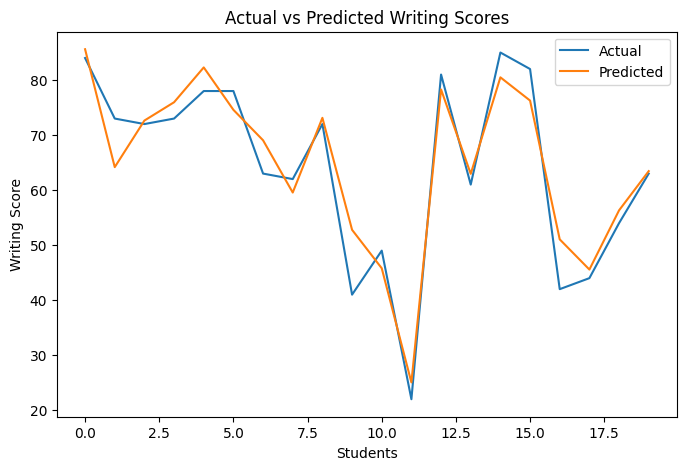

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(y_test.values[:20], label='Actual')
plt.plot(predictions[:20], label='Predicted')

plt.title("Actual vs Predicted Writing Scores")
plt.xlabel("Students")
plt.ylabel("Writing Score")

plt.legend()

plt.show()

In [31]:
import joblib

joblib.dump(model, 'student_model.pkl')

['student_model.pkl']